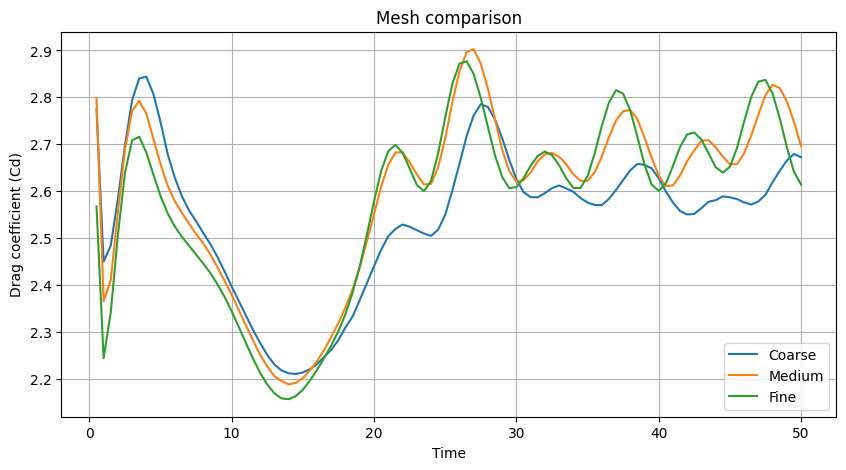

In [1]:
import numpy as np
import matplotlib.pyplot as plt

coarse = np.loadtxt("coarse.dat", comments="#")
medium = np.loadtxt("medium.dat", comments="#")
fine = np.loadtxt("fine.dat", comments="#")

t_c, cd_c = coarse[:,0], coarse[:,1]
t_m, cd_m = medium[:,0], medium[:,1]
t_f, cd_f = fine[:,0], fine[:,1]

plt.figure(figsize=(10,5))
plt.plot(t_c, cd_c, label="Coarse")
plt.plot(t_m, cd_m, label="Medium")
plt.plot(t_f, cd_f, label="Fine")
plt.xlabel("Time")
plt.ylabel("Drag coefficient (Cd)")
plt.title("Mesh comparison")
plt.legend()
plt.grid()

plt.show()

In [2]:
Cd_c = cd_c[-1]
Cd_m = cd_m[-1]
Cd_f = cd_f[-1]

print("Coarse Cd:", Cd_c)
print("Medium Cd:", Cd_m)
print("Fine Cd:", Cd_f)

Coarse Cd: 2.672285
Medium Cd: 2.695949
Fine Cd: 2.613874


In [3]:
import numpy as np

# ---- velg tidsvindu for analyse ----
t_start = 30.0

mask_c = t_c >= t_start
mask_m = t_m >= t_start
mask_f = t_f >= t_start

# representativ størrelse: middelverdi av Cd i siste del
phi3 = np.mean(cd_c[mask_c])   # coarse
phi2 = np.mean(cd_m[mask_m])   # medium
phi1 = np.mean(cd_f[mask_f])   # fine

print("phi coarse =", phi3)
print("phi medium =", phi2)
print("phi fine   =", phi1)

# ---- antall celler i hver mesh ----
N3 = 2300   # coarse
N2 = 5478  # medium
N1 = 13248   # fine

d = 2    # 2D simulering, bruk 3 hvis 3D

r21 = (N1 / N2)**(1/d)
r32 = (N2 / N3)**(1/d)

print("r21 =", r21)
print("r32 =", r32)

# hvis r21 ~= r32 kan du bruke denne enkle formelen
r = r21

p = np.log(abs((phi3 - phi2) / (phi2 - phi1))) / np.log(r)
print("Observed order p =", p)

# Richardson extrapolation
phi_ext = phi1 + (phi1 - phi2) / (r**p - 1)
print("Extrapolated value =", phi_ext)

# approximate relative errors
ea21 = abs((phi1 - phi2) / phi1)
ea32 = abs((phi2 - phi3) / phi2)

# GCI
Fs = 1.25
GCI21 = Fs * ea21 / (r**p - 1) * 100
GCI32 = Fs * ea32 / (r**p - 1) * 100

print("GCI21 (%) =", GCI21)
print("GCI32 (%) =", GCI32)

# asymptotic range check
AR = GCI32 / (r**p * GCI21)
print("Asymptotic range check =", AR)

phi coarse = 2.6016736097560975
phi medium = 2.6917975365853657
phi fine   = 2.692945024390244
r21 = 1.5551208558283185
r32 = 1.5432884145339725
Observed order p = 9.882410604338155
Extrapolated value = 2.6929598230074596
GCI21 (%) = 0.0006869160473820938
GCI32 (%) = 0.05397352541828091
Asymptotic range check = 1.0004262905323609
